# Task: Analyze Token Transaction Behavior from Simulated Web3 Wallet Data

### Objective:
Analyze a dataset of on-chain token transfers to identify wallet behaviors, token usage trends, and total transaction volumes using Pandas and NumPy.

### Dataset Description:
Each row represents a token transfer between wallets.
Download Data Here

### Task Requirements:
NOTE: You may simulate this dataset using numpy and pandas if actual data isn't available.

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Solutions
#### 🔹 1. Data Preparation

In [3]:
#
# Load the dataset from a CSV or generate 500–1000 random rows using numpy (e.g., random wallets, tokens, amounts).

df = pd.read_csv('database/web3_token_transfers.csv')


In [7]:


# Parse the timestamp column as datetime using pd.to_datetime.

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['timestamp']


0     2024-07-27 03:58:20
1     2024-07-14 03:04:09
2     2024-07-29 07:29:38
3     2024-07-20 06:26:24
4     2024-07-13 23:07:51
              ...        
995   2024-07-19 20:23:42
996   2024-07-06 01:06:21
997   2024-07-29 12:05:32
998   2024-07-27 03:40:11
999   2024-07-21 23:44:32
Name: timestamp, Length: 1000, dtype: datetime64[ns]

### 🔹 2. Basic Exploration (Pandas)

In [8]:

# Show the top 5

df.head(5)

,sender_wallet,receiver_wallet,token,amount,timestamp,gas_used,tx_fee_usd
0,0xaed548b0ad2ad42d36a65fc9fbb7365290273735,0x6f0fa65da6805b547779f78d7ad8e2a1247cd860,UNI,234.63,2024-07-27 03:58:20,78134,3.71
1,0xadebdbe4ffde843c5c0942476dafed98f4081ed2,0xfab70b3d71fab174410d390a80a1377c72a41251,USDC,1505.06,2024-07-14 03:04:09,41491,9.32
2,0xe380d92bab460b09297a542e4b0198e2c87e43c6,0x322edf020491e29d79318e73fb976d1c4bf159e2,WBTC,658.37,2024-07-29 07:29:38,22341,2.63
3,0x262afa887ea89b1b66c12e70d25de9412bdf3ddb,0x8ce7e3767410f34c6db80d9bd87bb5503ae1a0e3,UNI,456.47,2024-07-20 06:26:24,65623,4.04
4,0x4d87bd4dc83166db001549b0f7dd10ed8172a979,0xaf6bb63813b74b9c62a370447287eb805b11c3ca,WBTC,84.81,2024-07-13 23:07:51,21338,4.60


In [9]:
# Show the bottom 5 rows

df.tail(5)

,sender_wallet,receiver_wallet,token,amount,timestamp,gas_used,tx_fee_usd
995,0x7d321f54337d3b2fe762d2f98cc65a08b33c8167,0x12b225c93d09fbfee50834d34bb976ba2ab744a4,USDC,48.03,2024-07-19 20:23:42,30503,1.63
996,0x99ffd9b436b447f0b75704c666c2e3387468aabc,0xad14eea793cb71aeec4914db1cd51b955768446a,USDC,1246.35,2024-07-06 01:06:21,81703,3.24
997,0xf2476d3a88703c2484581466c841db8ce62c411d,0x8233219c96b703195211f975be60343e130b66a5,WBTC,73.57,2024-07-29 12:05:32,85379,4.28
998,0xb7e4e6b50e93960442a38761471840f4a48cb869,0x199d63a67615ec83d45f91010f6c8206f711b2be,WBTC,1500.25,2024-07-27 03:40:11,78866,9.24
999,0xb21913e7f083654695aeeab90f1510468f1dc41e,0x9bca5940e7d53f22ca22245954f66ece9ab16af8,USDC,295.30,2024-07-21 23:44:32,37905,9.94


In [10]:
# Count the number of unique wallets (senders and receivers).
num_senders = df['sender_wallet'].nunique()
num_receivers = df['receiver_wallet'].nunique()
total = num_receivers + num_senders

print(f'Number of; \n 1. unique senders: {num_senders} \n 2. unique receivers: {num_receivers}\n Total: {total}')

Number of; 
 1. unique senders: 1000 
 2. unique receivers: 1000
 Total: 2000


In [11]:
# Count how many transactions each token has.
num_tx = df['token'].value_counts()
print(f'Number of transactions by token {num_tx}')

Number of transactions by token token
WBTC    214
ETH     203
USDC    200
UNI     194
DAI     189
Name: count, dtype: int64


### 🔹 3. Wallet Analysis

In [12]:
# Compute total amount sent by each wallet.

amount_sent = df.groupby('sender_wallet')['amount'].sum()
amount_sent


sender_wallet
0x0003c3872d1848ec2011e26ad7571c69370f9fd0     634.78
0x0034126c0d51266516fd65d12f3c9a67f04062fa     138.44
0x005f673297464a3a9b8657e7f9d1a19e6d62f0f7      26.53
0x00906f78509cf901863c7f6980e32877871b784e     452.03
0x00fafa59c53d3dd96f5ce0c922ea899710e33c56     136.02
                                               ...   
0xff9b9663adb0864f9be675097e1d9d12a685c9af     179.32
0xffab6a48a594ca3dea01cbcb44673475c863b7d1     380.27
0xffd0af93e3570caac85652b2842369c8c22befcd      23.26
0xffd362f45a8736314fa0278a959bf14c4f4ffdfe    1298.94
0xfff2203dcedf4f760a54ad07236a3498cbeab07b    1624.55
Name: amount, Length: 1000, dtype: float64

In [13]:
# Compute total amount received by each wallet.

amount_received = df.groupby('receiver_wallet')['amount'].sum()

amount_received


receiver_wallet
0x010ca7452031dca3995f59dcfa5a80446f2e4c03     191.37
0x0114a8e880508bfe99f6c996096380067a1c6b7a    2884.04
0x0147c9752252629711318f835142d3153726dbea     501.85
0x01a4c2ac00ef039936197a9bfa3d1bb99a75d923      60.27
0x01a5453728aaf20873b9ac9b236cdb28f08cb285      47.86
                                               ...   
0xff54d95ac2898ea829739527ac616afe509b21fc     137.31
0xff80cbb0b2e5a08050469495f0b9f7871e6befd1     119.74
0xff8439a0dd7607d6dbb0aa73fdac628dda059114      36.92
0xffaae95b2a8933e5f6d8ba337098e69e1a3b64f8     524.86
0xffb6056e48b4eec9ef93d6fb825d7736a5e1919c     656.28
Name: amount, Length: 1000, dtype: float64

In [14]:
# Add total received and sent to df
df_wallet = pd.DataFrame({'total sent': amount_sent, 'total received': amount_received}).fillna(0)

df_wallet

,total sent,total received
0x0003c3872d1848ec2011e26ad7571c69370f9fd0,634.78,0.00
0x0034126c0d51266516fd65d12f3c9a67f04062fa,138.44,0.00
0x005f673297464a3a9b8657e7f9d1a19e6d62f0f7,26.53,0.00
0x00906f78509cf901863c7f6980e32877871b784e,452.03,0.00
0x00fafa59c53d3dd96f5ce0c922ea899710e33c56,136.02,0.00
...,...,...
0xffab6a48a594ca3dea01cbcb44673475c863b7d1,380.27,0.00
0xffb6056e48b4eec9ef93d6fb825d7736a5e1919c,0.00,656.28
0xffd0af93e3570caac85652b2842369c8c22befcd,23.26,0.00
0xffd362f45a8736314fa0278a959bf14c4f4ffdfe,1298.94,0.00


In [15]:
# Identify the top 5 wallets by total amount sent (group + sum + sort).
top_senders = df_wallet.sort_values(by='total sent', ascending=False)
print(top_senders.head(5))


                                            total sent  total received
0xd538f9c05ec121d00f70a00aa58b4ea2b7339a54     4086.22             0.0
0x0a83fcafb15e96514ef61020d4c96714a42bd923     2884.04             0.0
0xcc3f561f13db4c0a50c9f71ef693cf59eef2ba25     2847.44             0.0
0x1172060a8e20eb50ab9194d2780e99a42c9ac008     2478.41             0.0
0x64182502c1b1b4d6584998fc33358956434d2dc4     2328.50             0.0


In [16]:
# Create a new column: net_flow = received - sent.
df_wallet['net_flow'] = df_wallet['total received'] - df_wallet['total sent']
print(df_wallet['net_flow'])

0x0003c3872d1848ec2011e26ad7571c69370f9fd0    -634.78
0x0034126c0d51266516fd65d12f3c9a67f04062fa    -138.44
0x005f673297464a3a9b8657e7f9d1a19e6d62f0f7     -26.53
0x00906f78509cf901863c7f6980e32877871b784e    -452.03
0x00fafa59c53d3dd96f5ce0c922ea899710e33c56    -136.02
                                               ...   
0xffab6a48a594ca3dea01cbcb44673475c863b7d1    -380.27
0xffb6056e48b4eec9ef93d6fb825d7736a5e1919c     656.28
0xffd0af93e3570caac85652b2842369c8c22befcd     -23.26
0xffd362f45a8736314fa0278a959bf14c4f4ffdfe   -1298.94
0xfff2203dcedf4f760a54ad07236a3498cbeab07b   -1624.55
Name: net_flow, Length: 2000, dtype: float64


### 🔹 4. Token Analysis

In [17]:
# Find the average, median, and standard deviation of amount per token (use .agg()).
stats = df.groupby('token')['amount'].agg(['mean', 'median', 'std'])
print(stats)


             mean   median         std
token                                 
DAI    454.243386  316.210  456.309472
ETH    505.486502  365.730  524.465758
UNI    478.323196  305.365  497.945907
USDC   518.157150  367.185  507.707334
WBTC   473.650093  349.240  443.158188


In [18]:
# Identify the token with the highest transaction volume (in total amount, not count).

volume_tx = pd.DataFrame({'tx volume': df.groupby('token')['amount'].sum()}) # Create dataframe to store volume

top_gee = volume_tx.sort_values(by='tx volume', ascending=False).head(1) # sort and store top value

print("Token with highest volume: \n")
top_gee


Token with highest volume: 



,tx volume
token,
USDC,103631.43


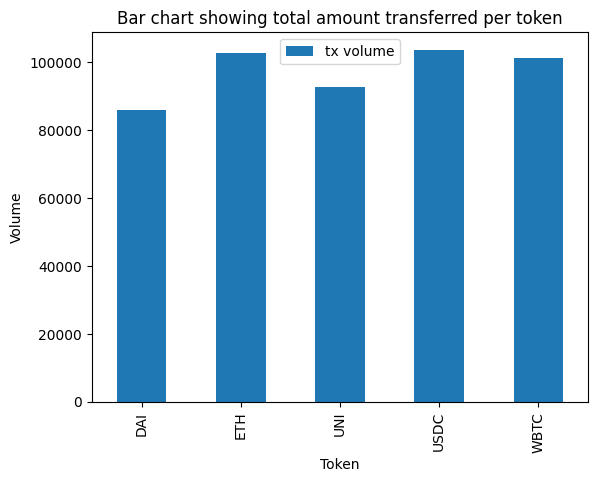

In [19]:
# Plot a bar chart showing total amount transferred per token using matplotlib.

volume_tx.plot(
    kind='bar',
    title= 'Bar chart showing total amount transferred per token'
)

plt.ylabel('Volume')
plt.xlabel('Token')
plt.show()

In [ ]:
df

,sender_wallet,receiver_wallet,token,amount,timestamp,gas_used,tx_fee_usd,date
0,0xaed548b0ad2ad42d36a65fc9fbb7365290273735,0x6f0fa65da6805b547779f78d7ad8e2a1247cd860,UNI,234.63,2024-07-27 03:58:20,78134,3.71,2024-07-27
1,0xadebdbe4ffde843c5c0942476dafed98f4081ed2,0xfab70b3d71fab174410d390a80a1377c72a41251,USDC,1505.06,2024-07-14 03:04:09,41491,9.32,2024-07-14
2,0xe380d92bab460b09297a542e4b0198e2c87e43c6,0x322edf020491e29d79318e73fb976d1c4bf159e2,WBTC,658.37,2024-07-29 07:29:38,22341,2.63,2024-07-29
3,0x262afa887ea89b1b66c12e70d25de9412bdf3ddb,0x8ce7e3767410f34c6db80d9bd87bb5503ae1a0e3,UNI,456.47,2024-07-20 06:26:24,65623,4.04,2024-07-20
4,0x4d87bd4dc83166db001549b0f7dd10ed8172a979,0xaf6bb63813b74b9c62a370447287eb805b11c3ca,WBTC,84.81,2024-07-13 23:07:51,21338,4.60,2024-07-13
...,...,...,...,...,...,...,...,...
995,0x7d321f54337d3b2fe762d2f98cc65a08b33c8167,0x12b225c93d09fbfee50834d34bb976ba2ab744a4,USDC,48.03,2024-07-19 20:23:42,30503,1.63,2024-07-19
996,0x99ffd9b436b447f0b75704c666c2e3387468aabc,0xad14eea793cb71aeec4914db1cd51b955768446a,USDC,1246.35,2024-07-06 01:06:21,81703,3.24,2024-07-06
997,0xf2476d3a88703c2484581466c841db8ce62c411d,0x8233219c96b703195211f975be60343e130b66a5,WBTC,73.57,2024-07-29 12:05:32,85379,4.28,2024-07-29
998,0xb7e4e6b50e93960442a38761471840f4a48cb869,0x199d63a67615ec83d45f91010f6c8206f711b2be,WBTC,1500.25,2024-07-27 03:40:11,78866,9.24,2024-07-27


### 🔹 5. Time-based Analysis

In [ ]:
# Convert timestamp to day
df['date'] = df['timestamp'].dt.date

# Group data by day and token (timestamp.dt.date) and compute:
tx_daily = df.groupby(['date','token']).agg(
    num_transactions = ('timestamp', 'count'),
    volume_daily = ('amount', 'sum'),
    avg_tx_size = ('amount', 'mean')
)

tx_daily

num_transactions  volume_daily  avg_tx_size
date       token                                             
2024-07-01 DAI                   6        981.03   163.505000
           ETH                  10       4437.94   443.794000
           UNI                   5       1365.56   273.112000
           USDC                  5       3315.54   663.108000
           WBTC                  2       1786.15   893.075000
...                            ...           ...          ...
2024-07-30 DAI                   5       3661.26   732.252000
           ETH                   4       3092.18   773.045000
           UNI                   8       4340.96   542.620000
           USDC                  7       2464.37   352.052857
           WBTC                  9       5295.82   588.424444

[148 rows x 3 columns]

In [ ]:
# Group data by day (timestamp.dt.date) and compute:
tx_daily = df.groupby('date').agg(
    num_transactions = ('timestamp', 'count'), # Number of transactions per day
    volume_daily = ('amount', 'sum'),           # Total volume per day
    avg_tx_size = ('amount', 'mean')            # Average transaction size per day
)

tx_daily

,num_transactions,volume_daily,avg_tx_size
date,,,
2024-07-01,28,11886.22,424.507857
2024-07-02,33,16560.16,501.823030
2024-07-03,23,8569.60,372.591304
2024-07-04,32,18195.10,568.596875
2024-07-05,34,13713.53,403.339118
2024-07-06,38,16442.27,432.691316
2024-07-07,38,17249.47,453.933421
2024-07-08,45,20232.45,449.610000
2024-07-09,40,15507.76,387.694000


### 🔹 6. Gas & Fee Analysis (NumPy + Pandas)

In [ ]:

# Use numpy to:
# Compute total gas used per token

gas_token = df.groupby('token')['gas_used'].sum()
gas_token


token
DAI     11918034
ETH     12163737
UNI     12054799
USDC    11967216
WBTC    12930658
Name: gas_used, dtype: int64

In [ ]:
# Calculate the average fee in USD using NumPy’s np.mean()

avg_fee = np.mean(df['tx_fee_usd'])
print("Average Tx Fee is:",avg_fee)


Average Tx Fee is: 5.24938


In [ ]:
# Identify the top 3 most expensive transactions (based on tx_fee_usd).
top_3_tx = df.sort_values(by='tx_fee_usd', ascending=False)

print(f'Top three most expensive tx are: {top_3_tx}')

Top three most expensive tx are:                                   sender_wallet  \
692  0xde9626a617067e8c9d9f5e53cf631139b4696d56   
117  0xb40ff3ae9391ca7df67ba9877a5b1ad2d2e15c5a   
75   0x44cb7ef9bc0528b331a9c8cbdd555eeda37cf0e4   
406  0xa30b61856ce264295712bbe296738492326d9031   
952  0x87e52662d4915dbddaeec7fa78afdf42cde546a2   
..                                          ...   
774  0x140dbefb4e187aef26f3f7869029df94570226fa   
84   0x3cf4a8e2a944a50021c54e44e3c7b5bbbdde2d5e   
490  0xa9b221ecd76ee050cbb60e5ff3c94ee76b51d221   
877  0x81febfd7b72a117139672367ac99f1a26c4a0011   
767  0xbdbd1f42e4598d02a8291ba604ba0aa1d24152da   

                                receiver_wallet token   amount  \
692  0x2d9e724bee9d687f456fcdd2a76132a7d58ada94   ETH   354.24   
117  0xa10e3155d329183ef464cbc77795c9f3d48d26db   DAI   103.25   
75   0x53777175d6fb4679ca72b7d2486e5cefce3cdc56   UNI   652.83   
406  0xa68f484ebe4b4a89a0527c8a70216968263cb0bd  USDC   246.49   
952  0xe1262e31426b9b14d

### 🔹 7. Advanced Challenges

In [ ]:
df = df.rename(columns={'date': 'day'}) ## Rename the column dat to day
# Create a pivot table: Rows = Token, Columns = Day, Values = Total amount transferred
pivot_table_df = df.pivot_table(
    index='token',          # Rows 
    columns='day',          # Columns
    values='amount',        # Values to aggregate
    aggfunc='sum'           # How to aggregate
)
pivot_table_df

day,2024-07-01,2024-07-02,2024-07-03,2024-07-04,2024-07-05,2024-07-06,2024-07-07,2024-07-08,2024-07-09,2024-07-10,...,2024-07-21,2024-07-22,2024-07-23,2024-07-24,2024-07-25,2024-07-26,2024-07-27,2024-07-28,2024-07-29,2024-07-30
token,,,,,,,,,,,,,,,,,,,,,
DAI,981.03,3293.77,1098.44,1429.71,2150.39,4961.15,1459.46,2778.56,5690.08,2873.41,...,4683.88,5082.96,1274.72,5799.61,2187.39,2362.51,3811.85,5424.34,2521.41,3661.26
ETH,4437.94,3387.59,2179.93,2631.23,2163.15,1396.71,5213.51,7382.79,1054.12,4103.09,...,1324.07,2011.65,1013.46,4403.55,3904.14,1632.84,2521.84,4941.49,1868.99,3092.18
UNI,1365.56,3226.33,1139.66,4812.17,3343.93,2662.74,2526.87,4525.55,2530.37,240.37,...,1186.67,4703.19,2651.29,3757.96,4080.85,4372.96,4908.37,4156.40,2501.23,4340.96
USDC,3315.54,4156.94,2153.10,5980.24,4019.92,3759.70,4501.74,1489.73,2647.31,3573.40,...,5045.03,3625.93,5466.10,3349.96,2314.46,1959.97,4458.44,3199.36,978.38,2464.37
WBTC,1786.15,2495.53,1998.47,3341.75,2036.14,3661.97,3547.89,4055.82,3585.88,935.94,...,7192.64,6496.35,6356.13,4042.02,4023.45,712.79,3548.41,5095.99,6346.91,5295.82


In [ ]:
# Use apply() to tag transactions as:
# low if amount < 100
# medium if 100 <= amount <= 1000
# high if amount > 1000

# Function to do the tagging
def tag_tx(amount):
    if amount < 100:
        return 'low'
    elif amount >= 100 and amount <= 1000:
        return 'medium'
    else: # If amount > 1000
        return 'high'
    
# Apply the function to create the 'trsansaction_tag' column
df['transaction_tag'] = df['amount'].apply(tag_tx)

print("DataFrame with 'transaction_tag' column:")
print(df[['amount', 'transaction_tag']].head()) # Displaying first few rows to verify

DataFrame with 'transaction_tag' column:
    amount transaction_tag
0   234.63          medium
1  1505.06            high
2   658.37          medium
3   456.47          medium
4    84.81             low


In [20]:
# Use np.where() to create a binary feature: is_large_tx (1 if amount > 1000, else 0)

df['is_large_tx'] = np.where(df['amount'] > 1000, 1, 0) # Create the 'is_large_tx' binary feature

print("\nDataFrame with 'is_large_tx' column:")
print(df[['amount', 'is_large_tx']].head()) # Displaying first few rows to verify


DataFrame with 'is_large_tx' column:
    amount  is_large_tx
0   234.63            0
1  1505.06            1
2   658.37            0
3   456.47            0
4    84.81            0


### 🔹 8. Bonus (Optional)

In [ ]:
# Merge two datasets: one for transfers and one for token prices (mock or real)

unique_tokens = df['token'].unique()
np.random.seed(42)

df_prices = pd.DataFrame({
    'token': unique_tokens,
    'token_price': np.random.uniform(0.5,500, size=len(unique_tokens))
})

df_merged = pd.merge(df, df_prices, on='token', how='left')

# Add a column for amount_usd = amount * token_price
df_merged['amount_usd'] = df_merged['amount'] * df_merged['token_price']

print('Mock Token Prices')
print(df_prices)

Mock Token Prices
  token  token_price
0   UNI   187.582789
1  USDC   475.381796
2  WBTC   366.130974
3   ETH   299.529913
4   DAI    78.431311


In [7]:
# Recalculate top tokens by USD volume

vol_tokens = df_merged.groupby('token')['amount_usd'].sum()
top_tokens = vol_tokens.sort_values(ascending=False)

print('Top 10 Tokens by USD volume:')
for i, (token, volume) in enumerate(top_tokens.items(), 1):
    print(f'{i}. {token}: ${volume:,.2f}')

Top 10 Tokens by USD volume:
1. USDC: $49,264,495.32
2. WBTC: $37,111,445.58
3. ETH: $30,735,890.59
4. UNI: $17,406,688.66
5. DAI: $6,733,484.90


In [ ]:
np.random.seed(42) # For consistent results

# --- Different Random Price Generations ---

# 1. Uniform Distribution (prices evenly spread between min and max)
df_prices_uniform = pd.DataFrame({
    'token': unique_tokens,
    'token_price': np.random.uniform(1, 1500, size=len(unique_tokens))
})
print('Uniform Prices (sample):\n', df_prices_uniform.head(3), '\n---')

# 2. Normal Distribution (prices cluster around a mean)
mean_price_norm, std_dev_norm = 500, 300
prices_normal = np.random.normal(loc=mean_price_norm, scale=std_dev_norm, size=len(unique_tokens))
prices_normal[prices_normal < 0.01] = 0.01 # Ensure non-negative
df_prices_normal = pd.DataFrame({
    'token': unique_tokens,
    'token_price': prices_normal
})
print('Normal Prices (sample):\n', df_prices_normal.head(3), '\n---')

# 3. Log-Normal Distribution (positively skewed, good for financial assets)
mean_log_price, std_dev_log_price = np.log(50), 1.5
df_prices_lognormal = pd.DataFrame({
    'token': unique_tokens,
    'token_price': np.exp(np.random.normal(mean_log_price, std_dev_log_price, size=len(unique_tokens)))
})
print('Log-Normal Prices (sample):\n', df_prices_lognormal.head(3), '\n---')

# 4. Conditional Pricing (specific rules for certain tokens)
df_prices_conditional = pd.DataFrame({
    'token': unique_tokens,
    'token_price': 0.0 # Placeholder
})
for i, token in enumerate(unique_tokens):
    if token in ['DAI', 'USDC']: # Stablecoins near $1
        df_prices_conditional.loc[df_prices_conditional['token'] == token, 'token_price'] = np.random.uniform(0.99, 1.01)
    elif token in ['BTC', 'ETH']: # Major high-value
        df_prices_conditional.loc[df_prices_conditional['token'] == token, 'token_price'] = np.random.uniform(1500, 50000)
    else: # Others
        df_prices_conditional.loc[df_prices_conditional['token'] == token, 'token_price'] = np.random.uniform(0.1, 500)
print('Conditional Prices (all tokens):\n', df_prices_conditional, '\n---')

Uniform Prices (sample):
   token  token_price
0   UNI   562.435638
1  USDC  1426.120745
2  WBTC  1098.258919 
---
Normal Prices (sample):
   token  token_price
0   UNI   583.712388
1  USDC   803.154585
2  WBTC   325.736560 
---
Log-Normal Prices (sample):
   token  token_price
0   UNI    12.502126
1  USDC     0.993223
2  WBTC   208.008206 
---
Conditional Prices (all tokens):
   token   token_price
0   UNI     69.832981
1  USDC      0.995843
2  WBTC    183.244285
3   ETH  23619.394235
4   DAI      1.005704 
---
